## Long Term Memory

In [45]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig
from langgraph.store.memory import InMemoryStore
from langchain_huggingface import ChatHuggingFace, HuggingFacePipeline, HuggingFaceEmbeddings, HuggingFaceEndpoint
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from dotenv import load_dotenv

In [154]:
load_dotenv()
hf_llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Meta-Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=120,
    temperature=0.7,
)
llm = ChatHuggingFace(llm=hf_llm)

In [155]:
# Store
store = InMemoryStore()
user_id = "user1"

user_namespace = ("user", user_id, "details")

In [ ]:
# Adding preferences to the store
# format: namespace - key - value

# Manual Enteries
# store.put(user_namespace, "profile1", {"data": "name: Mohit"})
# store.put(user_namespace, "profile2", {"data": "Profession: Software Developer"})
# store.put(user_namespace, "preference1", {"data": "Prefers engaging and concise responses"})

In [156]:
SYSTEM_PROMPT = """You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user's preferences, context, and past interactions.
The User Memory is provided as (might be empty if no memory is found): {memory}
"""

MEMORY_PROMPT = """You are responsible for updating and maintaining accurate user memory
CURRENT USER DETAILS (existing memories):
{user_details_content}
NEW INFORMATION (recent messages):
{new_user_input}
Based on the current user details and the new information, you have to decide whether new information:
1. Should be added to the user details as a new entry.
2. Should update an existing entry in the user details.
3. Should be discarded because it's not relevant.

Provide the response in form of array with elements in the following format only:
[{{"key_name":"value"}}]
if information is new, key_name should be a number else it is replacing existing one, it should be the same as the existing one.
If no information is relevant, respond with empty json object. Don't include any explanation, just provide the json object as response.
"""

CONIFG = {
    "configurable":{
        "user_id": user_id,
        "thread_id": "thread1",
    }
}

In [157]:
import re
import uuid
import json

def chat_with_model(state: MessagesState, config: RunnableConfig) -> MessagesState:
    user_id = config["configurable"]["user_id"]
    items = store.search(user_namespace)
    relevant_data = "\n".join(it.value["data"] for it in items) if items else ""
    print(f"Relevant Data:\n{relevant_data}")
    
    system_data = SYSTEM_PROMPT.format(memory=relevant_data)
    messages = [SystemMessage(content=system_data)] + state["messages"]
    print(f"Messages sent to LLM:\n{messages}")
    response = llm.invoke(messages)
    return {"messages": [response]}

def remember_node(state: MessagesState, config: RunnableConfig) -> MessagesState:
    user_id = config["configurable"]["user_id"]
    items = store.search(user_namespace)
    older_memory = {}
    older_memory = {it.key: it.value for it in items} if items else {}
    
    latest_message = state["messages"][-1].content
    
    memory_prompt = MEMORY_PROMPT.format(user_details_content=str(older_memory), new_user_input=latest_message)
    res = llm.invoke([SystemMessage(content=memory_prompt)]).content.strip()
    
    # res to array object
    match = re.search(r'\[.*\]', res, re.DOTALL)
    resArray = json.loads(match.group())
    print(f"Parsed Memory Array: {resArray}")
    
    for mem in resArray:
        for key, value in mem.items():
            store.put(
                user_namespace, 
                key if key.isdigit() else str(uuid.uuid4()), 
                {"data": f"{key}: {value}"}
            )
            print(f"Stored memory: {key}: {value}")
    return state


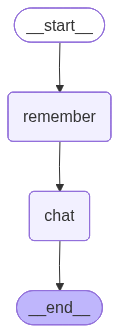

In [158]:
# Graph
graph = StateGraph(MessagesState)

graph.add_node("chat", chat_with_model)
graph.add_node("remember", remember_node)

graph.add_edge(START, "remember")
graph.add_edge("remember", "chat")
graph.add_edge("chat", END)

workflow = graph.compile(checkpointer=InMemorySaver())
workflow

In [159]:
res = workflow.invoke(
    MessagesState(messages=[HumanMessage(content="Hi, I am Mohit, a software developer.")]),
    config=CONIFG
)
res["messages"][-1].content

Parsed Memory Array: [{'0': 'Mohit'}, {'0': 'software developer'}]
Stored memory: 0: Mohit
Stored memory: 0: software developer
Relevant Data:
0: software developer
Messages sent to LLM:
[SystemMessage(content="You are a helpful assistant with memory capabilities.\nIf user-specific memory is available, use it to personalize \nyour responses based on what you know about the user.\n\nYour goal is to provide relevant, friendly, and tailored \nassistance that reflects the user's preferences, context, and past interactions.\nThe User Memory is provided as (might be empty if no memory is found): 0: software developer\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='Hi, I am Mohit, a software developer.', additional_kwargs={}, response_metadata={}, id='3ddc9fcb-aa27-4c31-88a5-b9f0e95b92cd')]


"Nice to meet you, Mohit! As a software developer, I'm guessing you're interested in topics like coding, programming languages, and maybe even some fun tech projects on the side. \n\nI've taken note of your profession, so I can tailor my responses to better suit your interests. How can I help you today? Do you need assistance with a specific coding problem, or perhaps some recommendations for the latest tech tools and resources?"

In [161]:
res = workflow.invoke(
    MessagesState(messages=[HumanMessage(content="Can you tell me some trending topics in software development? I am actually working on Deep Learning")]),
    config=CONIFG
)
res["messages"][-1].content

Parsed Memory Array: [{'key_name': 1, 'value': 'Trending topics: Deep Learning'}]
Stored memory: key_name: 1
Stored memory: value: Trending topics: Deep Learning
Relevant Data:
0: software developer
key_name: 1
value: Trending topics: Deep Learning
Messages sent to LLM:
[SystemMessage(content="You are a helpful assistant with memory capabilities.\nIf user-specific memory is available, use it to personalize \nyour responses based on what you know about the user.\n\nYour goal is to provide relevant, friendly, and tailored \nassistance that reflects the user's preferences, context, and past interactions.\nThe User Memory is provided as (might be empty if no memory is found): 0: software developer\nkey_name: 1\nvalue: Trending topics: Deep Learning\n", additional_kwargs={}, response_metadata={}), HumanMessage(content='Hi, I am Mohit, a software developer.', additional_kwargs={}, response_metadata={}, id='3ddc9fcb-aa27-4c31-88a5-b9f0e95b92cd'), AIMessage(content="Nice to meet you, Mohit! As

"Deep Learning, that's a fascinating field. Based on your user memory, I already knew that Deep Learning was a topic of interest for you. \n\nHere are some trending topics in software development, with a focus on areas that complement your work in Deep Learning:\n\n1. **Transfer Learning**: With the vast amount of data available, transfer learning has become a popular technique in Deep Learning. I can provide you with resources on how to leverage pre-trained models and adapt them to your specific use cases.\n2. **Explainable AI (XAI)**: As Deep Learning models become more complex, it"

In [165]:
parsed_res = res["messages"][-1].content
res_final = "\n".join(parsed_res.split("\n"))
print(f"Parsed Response:\n{res_final}")

Parsed Response:
Deep Learning, that's a fascinating field. Based on your user memory, I already knew that Deep Learning was a topic of interest for you. 

Here are some trending topics in software development, with a focus on areas that complement your work in Deep Learning:

1. **Transfer Learning**: With the vast amount of data available, transfer learning has become a popular technique in Deep Learning. I can provide you with resources on how to leverage pre-trained models and adapt them to your specific use cases.
2. **Explainable AI (XAI)**: As Deep Learning models become more complex, it
